# Brasileirão Série A: probabilidades de resultado (A, D, H)

Competição Campeonato Inteli Módulo 3 2026. O objetivo é estimar, para cada partida do `test.csv`, a probabilidade de vitória do visitante (A), empate (D) e vitória do mandante (H), minimizando o LogLoss multiclasse.

O notebook se apoia em três decisões, e cada uma tem uma seção com a evidência que a sustenta:

- **Alvo de mercado.** O modelo aprende a reproduzir a probabilidade implícita das odds de fechamento do treino, em vez de aprender direto do resultado. O resultado de uma partida é uma amostra muito ruidosa da probabilidade verdadeira, e o mercado é uma estimativa bem mais estável da mesma quantidade.
- **Regime de mando reduzido.** Entre agosto de 2020 e setembro de 2021 a vantagem do mandante cai de forma abrupta no treino e depois volta. Uma feature calculada pela data da própria linha isola esse período, para que ele não contamine a previsão de 2022 em diante.
- **Busca evolutiva entre famílias de modelos.** Oito famílias de modelos do Scikit-Learn competem em uma busca com seleção, cruzamento e mutação. A meta da busca é chegar o mais perto possível do LogLoss do mercado na validação, que é o piso de quem só tem informação pública.

Regras que o notebook respeita e deixa verificáveis:

- O código usa apenas NumPy, Pandas e Scikit-Learn para modelagem, e Matplotlib para visualização.
- Nenhum dado externo entra no pipeline, tudo vem de `train.csv` e `test.csv`.
- Cada previsão do teste usa somente as colunas da própria linha, e a seção 11 testa isso prevendo linha a linha.
- A validação é temporal, separada por temporada, sem shuffle.
- O placar público não entra em nenhuma decisão, todas as escolhas saem da validação local.

O registro completo de decisões e testes está em `docs/decisoes.md` e `docs/experimentos.md`.

## 1. Setup

In [1]:
import os
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestRegressor, ExtraTreesRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import log_loss

warnings.filterwarnings("ignore")

SEED = 42
CLASSES = ["A", "D", "H"]  # ordem alfabetica, a mesma que o log_loss do sklearn usa

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)

In [2]:
def find_data_dir():
    # procura os CSVs na variavel de ambiente, na pasta local e no caminho padrao do Kaggle
    candidates = [
        os.environ.get("BRASILEIRAO_DATA"),
        "data",
        ".",
        "/kaggle/input/campeonato-inteli-modulo-3-2026",
    ]
    for c in candidates:
        if c and (Path(c) / "train.csv").exists() and (Path(c) / "test.csv").exists():
            return Path(c)
    raise FileNotFoundError("Coloque train.csv, test.csv e sample_submission.csv na pasta data/")


DATA_DIR = find_data_dir()
train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
sample = pd.read_csv(DATA_DIR / "sample_submission.csv")

print("train:", train.shape, "| test:", test.shape, "| sample:", sample.shape)
train.head()

train: (3419, 26) | test: (1725, 22) | sample: (1725, 4)


,Id,Season,Date,Home,Away,elo_home,elo_away,elo_diff,form_pts_home,form_pts_away,form_gf_home,form_ga_home,form_gf_away,form_ga_away,home_form_as_host,away_form_as_visitor,rest_days_home,rest_days_away,season_ppg_home,season_ppg_away,round_n,h2h_home_pts,Res,odd_casa,odd_empate,odd_visitante
0,0,2013,2013-05-25,Vasco,Portuguesa,1506.636452,1486.580590,20.055862,1.6,1.0,1.2,1.4,0.8,1.2,0.4,1.0,174.0,174.0,NaN,NaN,1,3.0,H,1.86,3.44,4.06
1,1,2013,2013-05-25,Vitoria,Internacional,1500.000000,1490.971962,9.028038,NaN,0.2,NaN,NaN,0.0,1.6,NaN,0.8,NaN,174.0,NaN,NaN,1,NaN,D,2.72,3.17,2.52
2,2,2013,2013-05-26,Corinthians,Botafogo RJ,1527.354763,1506.560479,20.794285,2.0,1.0,2.2,1.0,1.8,1.8,2.2,1.2,175.0,176.0,NaN,NaN,1,0.0,D,1.82,3.43,4.21
3,3,2013,2013-05-26,Criciuma,Bahia,1500.000000,1498.594997,1.405003,NaN,2.0,NaN,NaN,1.0,0.8,NaN,1.4,NaN,175.0,NaN,NaN,1,NaN,H,1.72,3.50,4.70
4,4,2013,2013-05-26,Gremio,Nautico,1561.732962,1489.510755,72.222206,2.2,1.4,1.8,1.0,1.2,0.8,1.8,0.4,175.0,175.0,NaN,NaN,1,3.0,H,1.38,4.36,8.19


## 2. Leitura inicial dos dados

Antes de modelar, vale conferir três coisas: a distribuição do resultado por temporada, a quantidade de valores ausentes por coluna, e se as temporadas do treino e do teste realmente não se sobrepõem.

In [3]:
seasons = [int(s) for s in sorted(train.Season.unique())]
print("temporadas treino:", seasons)
print("temporadas teste :", [int(s) for s in sorted(test.Season.unique())])
assert train.Season.max() < test.Season.min(), "treino e teste deveriam ser separados no tempo"

dist = train.groupby("Season").Res.value_counts(normalize=True).unstack()[CLASSES]
dist["n"] = train.groupby("Season").size()
print(dist.round(3))

faltantes = pd.DataFrame({"train": train.isna().sum(), "test": test.isna().sum()}).fillna(0).astype(int)
print(faltantes[faltantes.sum(axis=1) > 0])
print("times do teste que nao aparecem no treino:", sorted((set(test.Home) | set(test.Away)) - (set(train.Home) | set(train.Away))))

temporadas treino: [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]
temporadas teste : [2022, 2023, 2024, 2025, 2026]
Res         A      D      H    n
Season                          
2013    0.232  0.284  0.484  380
2014    0.239  0.242  0.518  380
2015    0.234  0.239  0.526  380
2016    0.219  0.248  0.533  379
2017    0.289  0.271  0.439  380
2018    0.179  0.289  0.532  380
2019    0.258  0.258  0.484  380
2020    0.266  0.284  0.450  380
2021    0.245  0.297  0.458  380
                      train  test
away_form_as_visitor     16     2
form_ga_away              9     2
form_ga_home              7     0
form_gf_away              9     2
form_gf_home              7     0
form_pts_away             9     2
form_pts_home             7     0
h2h_home_pts            656   112
home_form_as_host        16     2
rest_days_away            9     2
rest_days_home            7     0
season_ppg_away          90    50
season_ppg_home          90    50
times do teste que nao aparecem no tr

A frequência de vitória do mandante oscila entre 44% e 53% de uma temporada para outra, e boa parte dessa oscilação é ruído de amostra com 380 jogos. Os valores ausentes se concentram na primeira rodada de cada temporada (`season_ppg`) e em confrontos sem histórico (`h2h_home_pts`), então a imputação pela mediana do treino resolve sem distorcer.

## 3. Alvo: resultado real e probabilidade do mercado

As odds trazem a margem da casa embutida, então a soma dos inversos passa de 1. A forma mais comum de tirar a margem é dividir cada inverso pela soma, mas isso assume que a margem é distribuída de forma proporcional entre os três resultados. Na prática a casa carrega mais margem nos azarões, e a normalização proporcional deixa os favoritos com probabilidade menor do que deveriam ter.

O método da potência corrige isso. Para cada partida ele procura o expoente `k` que faz a soma de `(1/odd)^k` dar exatamente 1, o que tira mais margem de quem tem odd alta. A busca é feita por bisseção em NumPy. A célula abaixo compara os dois métodos pelo LogLoss contra o resultado real.

In [4]:
def onehot(res):
    # matriz n x 3 na ordem A, D, H
    return np.stack([(res == c).to_numpy(dtype=float) for c in CLASSES], axis=1)


def inverse_odds(df):
    return np.stack([1 / df.odd_visitante, 1 / df.odd_empate, 1 / df.odd_casa], axis=1)


def devig_proporcional(Q):
    return Q / Q.sum(axis=1, keepdims=True)


def devig_potencia(Q, n_iter=60):
    lo, hi = np.ones(len(Q)), np.full(len(Q), 3.0)
    for _ in range(n_iter):
        k = (lo + hi) / 2
        soma = (Q ** k[:, None]).sum(axis=1)
        lo, hi = np.where(soma > 1, k, lo), np.where(soma > 1, hi, k)
    P = Q ** ((lo + hi) / 2)[:, None]
    return P / P.sum(axis=1, keepdims=True)


Y_all = onehot(train.Res)
Q_all = inverse_odds(train)
assert np.isfinite(Q_all).all(), "ha partidas sem odds no treino"

print("margem media do mercado        :", round(float(Q_all.sum(axis=1).mean() - 1), 4))
print("LogLoss da frequencia historica:", round(log_loss(train.Res, np.tile(Y_all.mean(0), (len(train), 1)), labels=CLASSES), 4))
print("LogLoss mercado, proporcional  :", round(log_loss(train.Res, devig_proporcional(Q_all), labels=CLASSES), 4))
print("LogLoss mercado, potencia      :", round(log_loss(train.Res, devig_potencia(Q_all), labels=CLASSES), 4))

M_all = devig_potencia(Q_all)


def target(idx, alpha):
    # alpha e o peso do mercado no alvo: 0 usa so o resultado, 1 usa so o mercado
    return alpha * M_all[idx] + (1 - alpha) * Y_all[idx]

margem media do mercado        : 0.0693
LogLoss da frequencia historica: 1.0446
LogLoss mercado, proporcional  : 0.997
LogLoss mercado, potencia      : 0.996


O mercado fica perto de 1.00 no treino, e esse número é a referência do melhor que dá para chegar com informação pública. O modelo com as colunas da base deve ficar acima dele, porque o mercado conhece escalação, lesões e contexto que as features não trazem.

## 4. Features

Toda feature nova sai de operações entre colunas da mesma linha. Não existe `groupby`, `shift`, `rolling`, ordenação por data ou qualquer outra operação que olhe para outra partida. Isso garante por construção a regra de usar só a própria linha do teste.

As features ficam organizadas em grupos, e cada grupo tem uma versão bruta (mandante e visitante em colunas separadas) e uma versão em diferença (mandante menos visitante). A busca evolutiva da seção 8 decide quais grupos entram e em qual versão.

- **Elo.** A diferença de Elo ou os dois ratings separados sempre entram, porque concentram quase todo o sinal. O módulo da diferença é opcional e serve para o empate, que é mais provável quando os times se equivalem.
- **Forma, gols e mando.** São as médias dos últimos 5 jogos, os gols feitos e sofridos, e a forma específica em casa e fora.
- **Pontos por jogo na temporada.** Na versão em diferença, o valor é multiplicado por `jogos / (jogos + 8)`, porque o `season_ppg` das primeiras rodadas vem de poucos jogos.
- **Descanso, confronto direto, rodada e calendário.** O descanso é cortado em 10 dias, e o calendário traz o mês e um indicador de jogo no meio da semana, os dois calculados a partir da data da própria linha.
- **Regime.** O indicador vale 1 para partidas entre agosto de 2020 e setembro de 2021, e 0 para todas as outras, incluindo todo o teste. A seção 7 mostra a evidência que define essa janela.
- **Nome dos times.** `Home` e `Away` entram como efeito fixo com regularização. O coeficiente de cada time é aprendido só no treino.

In [5]:
REGIME_INI, REGIME_FIM = "2020-08-01", "2021-09-30"  # janela definida pela analise da secao 7


def build_features(df):
    # usa SOMENTE colunas da propria linha (operacoes vetorizadas coluna a coluna)
    X = pd.DataFrame(index=df.index)
    X["Home"] = df.Home.astype(str)
    X["Away"] = df.Away.astype(str)
    for c in ["elo_home", "elo_away", "elo_diff", "form_pts_home", "form_pts_away", "form_gf_home", "form_ga_home",
              "form_gf_away", "form_ga_away", "home_form_as_host", "away_form_as_visitor",
              "season_ppg_home", "season_ppg_away", "h2h_home_pts", "round_n"]:
        X[c] = df[c]

    X["elo_diff_abs"] = df.elo_diff.abs()
    X["form_pts_diff"] = df.form_pts_home - df.form_pts_away
    X["form_gd_diff"] = (df.form_gf_home - df.form_ga_home) - (df.form_gf_away - df.form_ga_away)
    X["form_goals_total"] = df.form_gf_home + df.form_ga_home + df.form_gf_away + df.form_ga_away
    X["venue_form_diff"] = df.home_form_as_host - df.away_form_as_visitor

    jogos = (df.round_n - 1).clip(lower=0)
    X["ppg_diff"] = (df.season_ppg_home - df.season_ppg_away) * jogos / (jogos + 8)

    X["rest_diff"] = df.rest_days_home.clip(0, 10) - df.rest_days_away.clip(0, 10)
    X["short_rest_home"] = (df.rest_days_home <= 3).astype(float)
    X["short_rest_away"] = (df.rest_days_away <= 3).astype(float)

    data = pd.to_datetime(df.Date)
    X["midweek"] = data.dt.dayofweek.isin([1, 2, 3]).astype(float)
    X["month"] = data.dt.month.astype(float)
    X["regime"] = ((data >= REGIME_INI) & (data <= REGIME_FIM)).astype(float)
    return X


# grupos de features: (versao bruta, versao em diferenca)
GROUPS = {
    "elo_abs": (["elo_diff_abs"], ["elo_diff_abs"]),
    "form": (["form_pts_home", "form_pts_away"], ["form_pts_diff"]),
    "gols": (["form_gf_home", "form_ga_home", "form_gf_away", "form_ga_away"], ["form_gd_diff", "form_goals_total"]),
    "mando": (["home_form_as_host", "away_form_as_visitor"], ["venue_form_diff"]),
    "ppg": (["season_ppg_home", "season_ppg_away"], ["ppg_diff"]),
    "descanso": (["rest_diff", "short_rest_home", "short_rest_away"],) * 2,
    "h2h": (["h2h_home_pts"],) * 2,
    "rodada": (["round_n"],) * 2,
    "calendario": (["midweek", "month"],) * 2,
}


def columns(g):
    cols = ["elo_home", "elo_away"] if g["repr"] == "bruto" else ["elo_diff"]
    i = 0 if g["repr"] == "bruto" else 1
    for nome, versoes in GROUPS.items():
        if g["g_" + nome]:
            cols = cols + versoes[i]
    if g["regime"]:
        cols = cols + ["regime"]
    return cols


X_all = build_features(train)
X_test = build_features(test)
assert X_test.regime.sum() == 0, "nenhuma partida do teste cai na janela do regime"
print("partidas do treino dentro do regime:", int(X_all.regime.sum()))

partidas do treino dentro do regime: 594


## 5. Famílias de modelos

Cada configuração de modelo é descrita por um dicionário de genes, que a busca evolutiva manipula. A classe `Modelo` lê os genes e monta o pipeline. O imputador, o scaler e o encoder de times são ajustados só com o treino. Times que não existem no treino recebem efeito zero.

As oito famílias usam três formas diferentes de aprender com um alvo que é uma probabilidade, e não uma classe:

- **Classificador com peso por classe (`logit`, `hgb`).** Cada partida entra três vezes no treino, uma para cada classe, com `sample_weight` igual à probabilidade alvo daquela classe. Isso minimiza exatamente a entropia cruzada contra o alvo suave.
- **Limiares empilhados (`ordinal`).** O modelo de odds proporcionais trata o resultado como ordenado (A, D, H) e ajusta uma regressão logística binária para os dois limiares, com os coeficientes compartilhados.
- **Regressão em log-odds (`ridge`, `mlp`).** O alvo vira o par `log(pA/pD)` e `log(pH/pD)`, e a previsão volta para probabilidade por softmax.
- **Regressão direta na probabilidade (`rf`, `et`, `knn`).** A previsão é uma média de vetores de probabilidade do treino, então já sai válida.

In [6]:
FAMILIES = ["logit", "ordinal", "ridge", "mlp", "hgb", "rf", "et", "knn"]
CONVEXAS = ["logit", "ordinal", "ridge"]  # otimo unico, resultado estavel entre versoes de biblioteca


class Modelo:
    def __init__(self, g):
        self.g, self.cols = g, columns(g)

    def _design(self, X, fit=False):
        g = self.g
        if fit:
            self.imp = SimpleImputer(strategy="median").fit(X[self.cols])
        Z = self.imp.transform(X[self.cols])
        if fit:
            self.sc = StandardScaler().fit(Z)
        Z = self.sc.transform(Z)
        if g["team_fx"]:
            if fit:
                if g["min_freq"]:
                    # times com poucos jogos no treino e times ineditos dividem uma categoria unica
                    self.ohe = OneHotEncoder(handle_unknown="infrequent_if_exist",
                                             min_frequency=g["min_freq"], sparse_output=False)
                else:
                    self.ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
                self.ohe.fit(X[["Home", "Away"]])
            Z = np.hstack([Z, self.ohe.transform(X[["Home", "Away"]])])
        return Z

    def fit(self, X, P, w=None):
        g, fam = self.g, self.g["family"]
        Z = self._design(X, fit=True)
        n = len(Z)
        w = np.ones(n) if w is None else np.asarray(w, dtype=float)
        C = 10 ** g["logC"]
        if fam in ("logit", "hgb"):
            wr = P.T.reshape(-1) * np.tile(w, 3)
            keep = wr > 0
            if fam == "logit":
                self.m = LogisticRegression(C=C, max_iter=3000)
            else:
                self.m = HistGradientBoostingClassifier(
                    max_depth=g["depth"], learning_rate=g["lr"], max_iter=g["n_iter"],
                    min_samples_leaf=g["leaf"], l2_regularization=1.0, random_state=SEED)
            self.m.fit(np.vstack([Z] * 3)[keep], np.repeat(np.arange(3), n)[keep], sample_weight=wr[keep])
        elif fam == "ordinal":
            t1, t2 = P[:, 1] + P[:, 2], P[:, 2]  # P(y > A) e P(y > D)
            Zs, ys, ws = [], [], []
            for limiar, t in [(0.0, t1), (1.0, t2)]:
                Zt = np.hstack([Z, np.full((n, 1), limiar)])
                for rotulo, wt in [(1, t), (0, 1 - t)]:
                    Zs.append(Zt)
                    ys.append(np.full(n, rotulo))
                    ws.append(wt * w)
            ws = np.concatenate(ws)
            keep = ws > 0
            self.m = LogisticRegression(C=C, max_iter=5000)
            self.m.fit(np.vstack(Zs)[keep], np.concatenate(ys)[keep], sample_weight=ws[keep])
        elif fam in ("ridge", "mlp"):
            Pc = np.clip(P, 1e-3, None)
            Pc = Pc / Pc.sum(axis=1, keepdims=True)
            T = np.stack([np.log(Pc[:, 0] / Pc[:, 1]), np.log(Pc[:, 2] / Pc[:, 1])], axis=1)
            if fam == "ridge":
                self.m = Ridge(alpha=1.0 / C).fit(Z, T, sample_weight=w)
            else:
                self.m = MLPRegressor(hidden_layer_sizes=(g["hidden"],), alpha=1.0 / C, solver="lbfgs",
                                      max_iter=400, random_state=SEED).fit(Z, T)
        elif fam in ("rf", "et"):
            cls = RandomForestRegressor if fam == "rf" else ExtraTreesRegressor
            self.m = cls(n_estimators=150, max_depth=g["depth"] + 2, min_samples_leaf=g["leaf"],
                         max_features=0.5, random_state=SEED, n_jobs=-1).fit(Z, P, sample_weight=w)
        elif fam == "knn":
            self.m = KNeighborsRegressor(n_neighbors=g["leaf"], weights="distance").fit(Z, P)
        return self

    def predict_proba(self, X):
        fam = self.g["family"]
        Z = self._design(X)
        n = len(Z)
        if fam in ("logit", "hgb"):
            P = self.m.predict_proba(Z)
        elif fam == "ordinal":
            g1 = self.m.predict_proba(np.hstack([Z, np.zeros((n, 1))]))[:, 1]
            g2 = self.m.predict_proba(np.hstack([Z, np.ones((n, 1))]))[:, 1]
            P = np.stack([1 - g1, g1 - g2, g2], axis=1)
        elif fam in ("ridge", "mlp"):
            T = self.m.predict(Z)
            E = np.exp(np.clip(np.stack([T[:, 0], np.zeros(n), T[:, 1]], axis=1), -6, 6))
            P = E / E.sum(axis=1, keepdims=True)
        else:
            P = self.m.predict(Z)
        P = np.clip(P, 1e-4, None)
        return P / P.sum(axis=1, keepdims=True)


def time_weights(s, half_life):
    # peso maior para temporadas recentes; half_life em temporadas, 0 desliga
    if not half_life:
        return None
    return (0.5 ** ((s.max() - s) / half_life)).to_numpy()


def fit_genome(g, idx):
    alpha = max(g["alpha"], 0.5) if g["family"] in ("ridge", "mlp") else g["alpha"]  # log-odds exige alvo sem zeros
    return Modelo(g).fit(X_all[idx], target(idx, alpha), time_weights(train.Season[idx], g["hl"]))

## 6. Validação temporal e meta

Três cortes de validação rodam para cada configuração, e nenhum deles embaralha as partidas:

- **Walk-forward (`wf`).** Para cada uma das cinco últimas temporadas do treino, o modelo treina com todas as temporadas anteriores e prevê a temporada seguinte.
- **Horizonte longo (`long`).** O modelo treina com as cinco primeiras temporadas e prevê as quatro últimas de uma vez.
- **Horizonte longo 2 (`long2`).** O modelo treina com as quatro primeiras temporadas e prevê as cinco últimas.

Os cortes de horizonte longo imitam melhor a tarefa real, em que o teste vai até cinco anos depois do fim do treino.

Cada configuração recebe duas notas. A nota `hard` é o LogLoss contra o resultado real, que é a métrica da competição. A nota `soft` é a entropia cruzada contra a probabilidade do mercado nas mesmas partidas. As duas estimam a mesma coisa, mas a `soft` tem muito menos ruído, porque compara probabilidade com probabilidade. O `fitness` da busca é a média das duas.

A **meta** é o LogLoss do próprio mercado nos cortes de validação. A coluna `gap_meta` mede quanto falta para o modelo chegar nele.

In [7]:
SPLITS = {
    "wf": [([s for s in seasons if s < v], [v]) for v in seasons[-5:]],
    "long": [(seasons[:5], seasons[5:])],
    "long2": [(seasons[:4], seasons[4:])],
}
for nome, sp in SPLITS.items():
    print(nome, "->", [(f"{tr[0]}-{tr[-1]}", va) for tr, va in sp])


def cross_entropy(T, P, mask=None):
    ok = ~np.isnan(P[:, 0])
    if mask is not None:
        ok = ok & mask
    return float(-(T[ok] * np.log(np.clip(P[ok], 1e-15, 1))).sum(axis=1).mean())


def ll(P, mask=None):
    return cross_entropy(Y_all, P, mask)


# confere que a metrica manual bate com o log_loss do sklearn na ordem A, D, H
_P = devig_proporcional(Q_all)
assert abs(ll(_P) - log_loss(train.Res, _P, labels=CLASSES)) < 1e-12


def oof_predict(g, splits):
    P = np.full((len(train), 3), np.nan)
    for tr_s, va_s in splits:
        tr = train.Season.isin(tr_s).to_numpy()
        va = train.Season.isin(va_s).to_numpy()
        P[va] = fit_genome(g, tr).predict_proba(X_all[va])
    return P


def score_predictions(P_by_split):
    out = {}
    for nome, P in P_by_split.items():
        out[nome], out[nome + "_soft"] = ll(P), cross_entropy(M_all, P)
    out["hard"] = float(np.mean([out[n] for n in SPLITS]))
    out["soft"] = float(np.mean([out[n + "_soft"] for n in SPLITS]))
    out["fitness"] = 0.5 * (out["hard"] + out["soft"])
    out["gap_meta"] = out["hard"] - META
    return out


ref = {}
for nome, sp in SPLITS.items():
    Pf = np.full((len(train), 3), np.nan)
    for tr_s, va_s in sp:
        Pf[train.Season.isin(va_s).to_numpy()] = Y_all[train.Season.isin(tr_s).to_numpy()].mean(0)
    ref[nome] = {"frequencia": ll(Pf), "mercado": ll(np.where(np.isnan(Pf), np.nan, M_all))}
    if nome == "wf":
        P_freq_wf = Pf
ref = pd.DataFrame(ref)
ref["media"] = ref.mean(axis=1)
META = float(ref.loc["mercado", "media"])
print("\nmeta (LogLoss do mercado, media dos cortes):", round(META, 4))
ref.round(4)

wf -> [('2013-2016', [2017]), ('2013-2017', [2018]), ('2013-2018', [2019]), ('2013-2019', [2020]), ('2013-2020', [2021])]
long -> [('2013-2017', [2018, 2019, 2020, 2021])]
long2 -> [('2013-2016', [2017, 2018, 2019, 2020, 2021])]

meta (LogLoss do mercado, media dos cortes): 0.9959


,wf,long,long2,media
frequencia,1.0590,1.0519,1.0599,1.0569
mercado,1.0016,0.9846,1.0016,0.9959


### Testes das decisões de base

Antes da busca, a tabela abaixo isola o efeito de cada decisão estrutural sobre uma regressão logística de referência. Cada linha muda uma coisa só em relação à linha `referencia`.

In [8]:
GENOMA_REF = dict(family="logit", repr="bruto", team_fx=True, min_freq=0, alpha=1.0, hl=4, logC=float(np.log10(0.2)),
                  depth=3, leaf=80, lr=0.03, n_iter=300, hidden=8, regime=True,
                  g_elo_abs=True, g_form=True, g_gols=True, g_mando=True, g_ppg=True, g_descanso=True,
                  g_h2h=True, g_rodada=True, g_calendario=False)

so_elo = {("g_" + n): False for n in GROUPS}
ablacoes = {
    "referencia": {},
    "alvo = resultado real (alpha 0)": dict(alpha=0.0),
    "alvo = metade mercado (alpha 0.5)": dict(alpha=0.5),
    "sem efeito de time": dict(team_fx=False),
    "sem feature de regime": dict(regime=False),
    "sem peso de recencia": dict(hl=0),
    "so diferenca de Elo": dict(repr="diff", **so_elo),
    "so diferenca de Elo, sem time, alvo real": dict(repr="diff", team_fx=False, alpha=0.0, **so_elo),
}
linhas = []
for nome, mudanca in ablacoes.items():
    g = dict(GENOMA_REF, **mudanca)
    linhas.append(dict(teste=nome, **score_predictions({k: oof_predict(g, sp) for k, sp in SPLITS.items()})))
abl = pd.DataFrame(linhas).set_index("teste")
abl[["wf", "long", "long2", "hard", "soft", "gap_meta"]].round(4)

,wf,long,long2,hard,soft,gap_meta
teste,,,,,,
referencia,1.0174,1.0065,1.0217,1.0152,1.0216,0.0193
alvo = resultado real (alpha 0),1.0483,1.0374,1.0575,1.0477,1.0570,0.0518
alvo = metade mercado (alpha 0.5),1.0258,1.0142,1.0297,1.0232,1.0309,0.0273
sem efeito de time,1.0212,1.0099,1.0237,1.0183,1.0245,0.0223
sem feature de regime,1.0189,1.0065,1.0217,1.0157,1.0217,0.0198
sem peso de recencia,1.0181,1.0070,1.0220,1.0157,1.0217,0.0198
so diferenca de Elo,1.0181,1.0079,1.0225,1.0162,1.0222,0.0202
"so diferenca de Elo, sem time, alvo real",1.0265,1.0145,1.0291,1.0233,1.0289,0.0274


A tabela sustenta três leituras. Trocar o alvo de mercado pelo resultado real é a mudança que mais piora o modelo, o que confirma a hipótese central. Tirar o efeito de time piora todos os cortes. A última linha é o modelo mais simples possível, uma regressão logística só com a diferença de Elo treinada no resultado, e a distância dela para a referência é o ganho acumulado das decisões deste notebook.

### Os efeitos de time sobrevivem a um horizonte de cinco anos?

Essa é a decisão mais arriscada do modelo, porque os elencos mudam e o teste vai até 2026. A célula abaixo treina com dados até um ano de corte e mede, para cada temporada seguinte, quanto o modelo com efeito de time ganha do modelo sem.

In [9]:
g_com, g_sem = dict(GENOMA_REF), dict(GENOMA_REF, team_fx=False)
linhas = []
for corte in seasons[2:-1]:
    tr = (train.Season <= corte).to_numpy()
    m_com, m_sem = fit_genome(g_com, tr), fit_genome(g_sem, tr)
    for s in [x for x in seasons if x > corte]:
        va = (train.Season == s).to_numpy()
        P_com = np.full((len(train), 3), np.nan)
        P_sem = np.full((len(train), 3), np.nan)
        P_com[va], P_sem[va] = m_com.predict_proba(X_all[va]), m_sem.predict_proba(X_all[va])
        linhas.append(dict(horizonte=s - corte,
                           ganho_resultado=ll(P_sem) - ll(P_com),
                           ganho_mercado=cross_entropy(M_all, P_sem) - cross_entropy(M_all, P_com)))
pd.DataFrame(linhas).groupby("horizonte").agg(["mean", "count"]).round(4)

ganho_resultado       ganho_mercado      
                     mean count          mean count
horizonte                                          
1                  0.0039     6        0.0035     6
2                  0.0026     5        0.0027     5
3                  0.0020     4        0.0026     4
4                  0.0009     3        0.0026     3
5                  0.0029     2        0.0021     2
6                  0.0025     1        0.0029     1

O ganho medido contra o mercado fica positivo em todos os horizontes e cai pouco com o tempo, então os efeitos de time ficam disponíveis para a busca.

## 7. Regime de mando reduzido

A célula abaixo treina a referência só com as temporadas até 2019 e compara, trimestre a trimestre, a probabilidade de vitória do mandante que o mercado deu com a que o modelo esperava. Se a vantagem do mandante fosse estável, o resíduo ficaria perto de zero.

             n  mercado_H  esperado_H  residuo_H  real_H
trimestre                                               
2018Q2     119      0.481       0.477      0.004   0.513
2018Q3     150      0.477       0.483     -0.007   0.553
2018Q4     111      0.483       0.487     -0.004   0.523
2019Q2      89      0.466       0.474     -0.008   0.573
2019Q3     126      0.491       0.485      0.006   0.468
2019Q4     165      0.481       0.484     -0.003   0.448
2020Q3     113      0.430       0.479     -0.048   0.442
2020Q4     155      0.437       0.490     -0.053   0.432
2021Q1     112      0.446       0.492     -0.046   0.482
2021Q2      70      0.447       0.490     -0.043   0.400
2021Q3     144      0.415       0.480     -0.064   0.368
2021Q4     166      0.466       0.486     -0.019   0.560

2021 mes a mes:
          n  mercado_H  residuo_H
mes                              
2021-05  10      0.463     -0.057
2021-06  60      0.444     -0.040
2021-07  58      0.423     -0.059
2021-08  49    

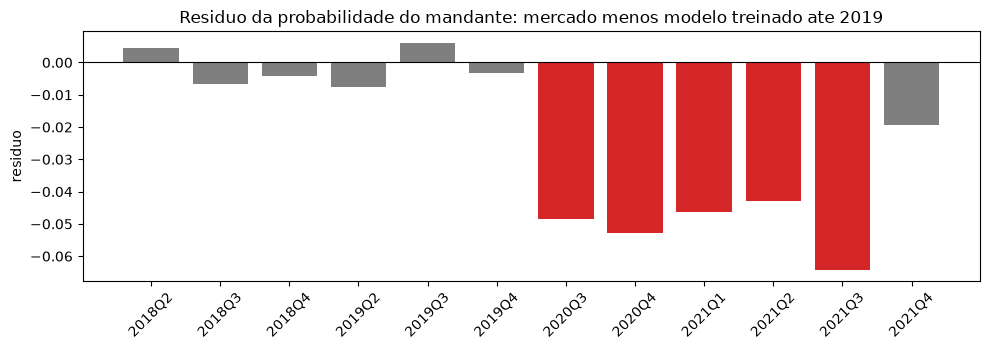

In [10]:
g_pre = dict(GENOMA_REF, regime=False, hl=0)
m_pre = fit_genome(g_pre, (train.Season <= 2019).to_numpy())
P_pre = m_pre.predict_proba(X_all)

datas = pd.to_datetime(train.Date)
res = pd.DataFrame({
    "trimestre": datas.dt.to_period("Q"),
    "mercado_H": M_all[:, 2],
    "esperado_H": P_pre[:, 2],
    "real_H": Y_all[:, 2],
})
res["residuo_H"] = res.mercado_H - res.esperado_H
tab = res[train.Season >= 2018].groupby("trimestre").agg(
    n=("residuo_H", "size"), mercado_H=("mercado_H", "mean"), esperado_H=("esperado_H", "mean"),
    residuo_H=("residuo_H", "mean"), real_H=("real_H", "mean"))
print(tab.round(3))

mensal = res[train.Season == 2021].assign(mes=datas[train.Season == 2021].dt.to_period("M")).groupby("mes").agg(
    n=("residuo_H", "size"), mercado_H=("mercado_H", "mean"), residuo_H=("residuo_H", "mean"))
print("\n2021 mes a mes:")
print(mensal.round(3))

fig, ax = plt.subplots(figsize=(10, 3.6))
cores = ["tab:red" if v < -0.03 else "tab:gray" for v in tab.residuo_H]
ax.bar(tab.index.astype(str), tab.residuo_H, color=cores)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Residuo da probabilidade do mandante: mercado menos modelo treinado ate 2019")
ax.set_ylabel("residuo")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

O resíduo fica perto de zero até o fim de 2019, cai para a faixa de 4 a 6 pontos percentuais negativos entre o terceiro trimestre de 2020 e o terceiro trimestre de 2021, e encolhe a partir de outubro de 2021. A quebra é abrupta nas duas pontas, o que descarta uma tendência gradual. A janela do regime vai de agosto de 2020 a setembro de 2021 por causa dessa tabela.

Isso importa porque as temporadas mais recentes pesam mais no treino. Sem tratamento, o modelo leva para 2022 em diante uma vantagem de mandante que o próprio treino mostra que já estava voltando ao normal no fim de 2021. Com a feature de regime, o modelo atribui a queda ao período e prevê o teste com a vantagem de mandante das partidas fora do regime.

A validação dessa decisão tem um limite que vale registrar. Só existem 166 partidas depois do fim do regime no treino (outubro a dezembro de 2021), então o teste abaixo é o único possível e tem amostra pequena.

In [11]:
pos = (datas > REGIME_FIM).to_numpy()
antes = ~pos
linhas = []
for nome, g in [("sem regime", dict(GENOMA_REF, regime=False)), ("com regime", dict(GENOMA_REF, regime=True))]:
    P = np.full((len(train), 3), np.nan)
    P[pos] = fit_genome(g, antes).predict_proba(X_all[pos])
    P_teste = fit_genome(g, np.ones(len(train), dtype=bool)).predict_proba(X_test)
    linhas.append(dict(modelo=nome, n=int(pos.sum()), hard=ll(P), soft=cross_entropy(M_all, P),
                       media_H_prevista=P[pos, 2].mean(), media_H_mercado=M_all[pos, 2].mean(),
                       media_H_no_teste=P_teste[:, 2].mean()))
pd.DataFrame(linhas).set_index("modelo").round(4)

,n,hard,soft,media_H_prevista,media_H_mercado,media_H_no_teste
modelo,,,,,,
sem regime,166,0.9747,1.0214,0.4633,0.4662,0.4628
com regime,166,0.9641,1.0216,0.4846,0.4662,0.4804


No período pós-regime os dois modelos empatam contra o mercado, porque outubro e novembro de 2021 ainda têm resíduo negativo e só dezembro volta ao nível anterior. Contra o resultado real o modelo com regime vai melhor, mas com 166 partidas isso não prova nada sozinho. A decisão de usar o regime se apoia na forma da quebra, que é abrupta e reverte, e não nesse teste.

O efeito prático aparece na última coluna. A previsão média de vitória do mandante no teste sobe cerca de 2 pontos percentuais com o regime. Como essa é uma aposta sobre o nível do mando em 2022 em diante, o notebook gera dois arquivos de submissão, um com regime e um sem, para que os dois possam ser escolhidos como submissões finais.

## 8. Busca evolutiva

A busca trata cada configuração como um indivíduo com genes. Os genes cobrem a família do modelo, a representação das features, quais grupos de features entram, o efeito de time, o peso do mercado no alvo, o peso de recência e os hiperparâmetros de cada família.

O ciclo de cada geração é o seguinte:

- **Avaliação.** Cada indivíduo é treinado e avaliado nos três cortes temporais, e recebe o `fitness` definido na seção 6.
- **Elitismo.** Os 4 melhores passam direto para a geração seguinte, para que a melhor solução nunca se perca.
- **Seleção por torneio.** Cada pai é o melhor entre 3 indivíduos sorteados, o que dá vantagem aos bons sem eliminar a diversidade.
- **Cruzamento uniforme.** O filho herda cada gene de um dos dois pais com probabilidade igual.
- **Mutação.** Cada gene tem 15% de chance de ser sorteado de novo, e a força da regularização sofre uma perturbação gaussiana com 50% de chance.

A população inicial tem 32 indivíduos. Oito são sementes, uma por família, todas com os genes da configuração de referência, para que nenhuma família dependa de sorte no sorteio inicial. Os outros 24 são aleatórios. A feature de regime fica ligada em todos, porque ela é uma decisão estrutural que a validação não consegue medir por inteiro. A semente do gerador é fixa, então a busca é reprodutível.

In [12]:
GENES = {
    "family": FAMILIES,
    "repr": ["bruto", "diff"],
    "team_fx": [True, False],
    "min_freq": [0, 20, 39],
    "alpha": [0.0, 0.5, 0.8, 1.0],
    "hl": [0, 8, 4, 2],
    "depth": [2, 3, 4, 6],
    "leaf": [20, 40, 80, 120, 200],
    "lr": [0.01, 0.02, 0.03, 0.05, 0.1],
    "n_iter": [100, 200, 300, 400],
    "hidden": [4, 8, 16],
}
for nome in GROUPS:
    GENES["g_" + nome] = [True, False]
LOGC = (-2.0, 0.7)


def genome_key(g):
    # so os genes que a familia usa entram na chave, para nao reavaliar individuos equivalentes
    fam = g["family"]
    usados = ["family", "repr", "team_fx", "alpha", "hl", "regime"] + ["g_" + n for n in GROUPS]
    if g["team_fx"]:
        usados.append("min_freq")
    if fam in ("logit", "ordinal", "ridge", "mlp"):
        usados.append("logC")
    if fam == "mlp":
        usados.append("hidden")
    if fam == "hgb":
        usados += ["depth", "leaf", "lr", "n_iter"]
    if fam in ("rf", "et"):
        usados += ["depth", "leaf"]
    if fam == "knn":
        usados.append("leaf")
    return json.dumps({k: (round(float(g[k]), 3) if k == "logC" else g[k]) for k in usados}, sort_keys=True)


CACHE = {}


def evaluate(g):
    k = genome_key(g)
    if k not in CACHE:
        CACHE[k] = score_predictions({nome: oof_predict(g, sp) for nome, sp in SPLITS.items()})
    return CACHE[k]


def random_genome(rng):
    g = {k: v[int(rng.integers(len(v)))] for k, v in GENES.items()}
    g["logC"] = float(rng.uniform(*LOGC))
    g["regime"] = True
    return g


def mutate(g, rng, taxa=0.15):
    h = dict(g)
    for k, v in GENES.items():
        if rng.random() < taxa:
            h[k] = v[int(rng.integers(len(v)))]
    if rng.random() < 0.5:
        h["logC"] = float(np.clip(h["logC"] + rng.normal(0, 0.3), *LOGC))
    return h


def crossover(a, b, rng):
    return {k: (a[k] if rng.random() < 0.5 else b[k]) for k in a}


def evolve(pop_size=32, generations=14, elite=4, seed=SEED):
    rng = np.random.default_rng(seed)
    pop = [random_genome(rng) for _ in range(pop_size)]
    for i, fam in enumerate(FAMILIES):
        pop[i] = dict(GENOMA_REF, family=fam)  # uma semente de referencia por familia
    log, resumo = [], []
    for ger in range(generations + 1):
        t0 = time.time()
        avaliados = sorted([(evaluate(g)["fitness"], i, g) for i, g in enumerate(pop)], key=lambda t: (t[0], t[1]))
        for fit, _, g in avaliados:
            log.append(dict(geracao=ger, **g, **evaluate(g)))
        melhor = avaliados[0]
        r = evaluate(melhor[2])
        resumo.append(dict(geracao=ger, melhor_fitness=melhor[0], hard=r["hard"], soft=r["soft"], gap_meta=r["gap_meta"],
                           mediana_fitness=float(np.median([a[0] for a in avaliados])), familia=melhor[2]["family"],
                           familias_vivas=len(set(a[2]["family"] for a in avaliados)), segundos=round(time.time() - t0)))
        if ger == generations:
            break
        nova = [a[2] for a in avaliados[:elite]]
        while len(nova) < pop_size:
            pais = [avaliados[int(min(rng.integers(len(avaliados), size=3)))][2] for _ in range(2)]
            nova.append(mutate(crossover(pais[0], pais[1], rng), rng))
        pop = nova
    return pd.DataFrame(log), pd.DataFrame(resumo)


t0 = time.time()
evo_log, evo_resumo = evolve()
print("tempo da busca: %.0f s | configuracoes unicas avaliadas: %d" % (time.time() - t0, len(CACHE)))
evo_resumo.round(4)

tempo da busca: 267 s | configuracoes unicas avaliadas: 404


,geracao,melhor_fitness,hard,soft,gap_meta,mediana_fitness,familia,familias_vivas,segundos
0,0,1.0184,1.0152,1.0216,0.0193,1.0280,logit,8,54
1,1,1.0184,1.0152,1.0216,0.0193,1.0219,logit,7,59
2,2,1.0184,1.0152,1.0216,0.0193,1.0198,logit,6,20
3,3,1.0181,1.0145,1.0216,0.0186,1.0197,ridge,5,10
4,4,1.0181,1.0145,1.0216,0.0186,1.0192,ridge,4,10
5,5,1.0181,1.0145,1.0216,0.0186,1.0192,ridge,7,20
6,6,1.0179,1.0144,1.0215,0.0185,1.0191,ridge,5,9
7,7,1.0179,1.0144,1.0215,0.0185,1.0193,ridge,5,16
8,8,1.0179,1.0142,1.0215,0.0183,1.0191,ridge,6,13
9,9,1.0179,1.0142,1.0215,0.0183,1.0187,ridge,4,8


### Leitura da busca

As tabelas abaixo mostram o melhor indivíduo de cada família, os melhores indivíduos no geral, e a fração dos 20 melhores que usa cada grupo de features.

melhor individuo de cada familia:
 family  repr  team_fx  min_freq  alpha  hl    logC     wf   long  long2   hard   soft  fitness  gap_meta
  ridge  diff     True         0    1.0   4 -1.2637 1.0168 1.0051 1.0207 1.0142 1.0215   1.0179    0.0183
  logit bruto     True         0    1.0   2 -0.5094 1.0167 1.0065 1.0216 1.0149 1.0216   1.0183    0.0190
    mlp bruto     True         0    1.0   4 -0.6990 1.0161 1.0076 1.0212 1.0149 1.0230   1.0190    0.0190
ordinal bruto     True         0    1.0   4 -0.6679 1.0178 1.0083 1.0226 1.0162 1.0221   1.0192    0.0203
    hgb bruto     True         0    1.0   4 -0.7745 1.0186 1.0073 1.0231 1.0164 1.0223   1.0193    0.0204
     rf  diff     True         0    1.0   4 -1.2637 1.0240 1.0131 1.0264 1.0212 1.0268   1.0240    0.0253
    knn bruto     True         0    1.0   4 -1.7977 1.0259 1.0163 1.0289 1.0237 1.0316   1.0276    0.0278
     et bruto     True         0    1.0   4 -0.6936 1.0302 1.0226 1.0329 1.0286 1.0342   1.0314    0.0327

10 melhores

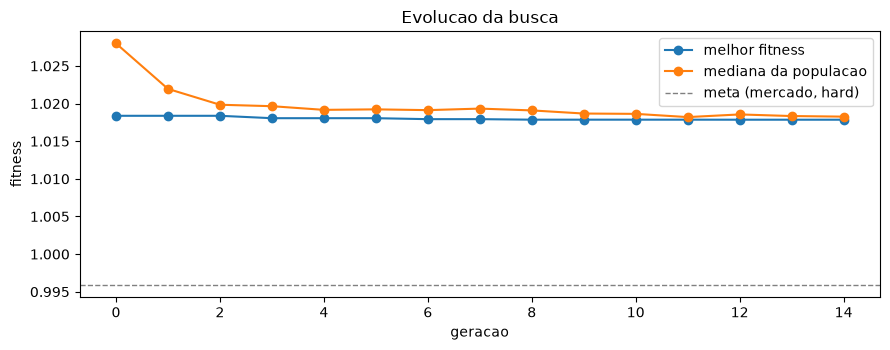

In [13]:
unicos = evo_log.drop_duplicates(subset=["fitness", "hard", "soft"]).sort_values("fitness").reset_index(drop=True)
cols_gene = ["family", "repr", "team_fx", "min_freq", "alpha", "hl", "logC"]
cols_nota = ["wf", "long", "long2", "hard", "soft", "fitness", "gap_meta"]

print("melhor individuo de cada familia:")
print(unicos.loc[unicos.groupby("family").fitness.idxmin()].sort_values("fitness")[cols_gene + cols_nota].round(4).to_string(index=False))
print("\n10 melhores individuos:")
print(unicos.head(10)[cols_gene + cols_nota].round(4).to_string(index=False))
print("\nfracao dos 20 melhores que usa cada grupo de features:")
print(unicos.head(20)[["g_" + n for n in GROUPS]].mean().round(2).to_string())

Path("docs").mkdir(exist_ok=True)
evo_log.round(6).to_csv("docs/evolucao_log.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.plot(evo_resumo.geracao, evo_resumo.melhor_fitness, marker="o", label="melhor fitness")
ax.plot(evo_resumo.geracao, evo_resumo.mediana_fitness, marker="o", label="mediana da populacao")
ax.axhline(META, color="gray", linestyle="--", linewidth=1, label="meta (mercado, hard)")
ax.set_xlabel("geracao")
ax.set_ylabel("fitness")
ax.set_title("Evolucao da busca")
ax.legend()
plt.tight_layout()
plt.show()

A busca deixa duas conclusões, e a segunda é a mais importante.

A primeira é sobre as famílias. Os modelos lineares treinados no alvo de mercado (`ridge` em log-odds e `logit`) ficam na frente. A rede neural pequena, o modelo ordinal e o gradient boosting vêm logo atrás, e as famílias de floresta e vizinhança ficam mais longe. Com pouco mais de 3 mil partidas e uma relação quase linear entre força e resultado, flexibilidade a mais só acrescenta variância.

A segunda é sobre o tamanho do ganho. A nota `soft` do melhor indivíduo quase não muda da geração 0 para a última, enquanto a nota `hard` melhora cerca de um milésimo. Como a `soft` é a medida de menor ruído, a leitura mais honesta é que a busca chegou a um platô já nas sementes, e que parte da melhora na `hard` é ajuste ao ruído da validação. O modelo não chega mais perto da meta porque a informação que falta não está nas colunas da base.

## 9. Ensemble final

O modelo final é a média das probabilidades dos 5 melhores indivíduos das famílias convexas (`logit`, `ordinal`, `ridge`), com no máximo 3 por família. Duas razões sustentam essa regra:

- **Variância da escolha.** A diferença entre os melhores indivíduos é menor que o ruído da validação, então a média de vários é mais confiável do que qualquer um deles sozinho.
- **Reprodutibilidade.** As famílias convexas têm ótimo único, e o resultado delas não muda com a versão da biblioteca ou com a máquina. A rede neural e as árvores ficam fora do modelo final por isso, mesmo empatando na validação.

Os genomas escolhidos são gravados em `artefatos/genomas_finais.json`. Se a busca for executada em outro ambiente e chegar a indivíduos diferentes por diferença numérica, o notebook avisa e usa os genomas gravados, para que o arquivo de submissão seja sempre o mesmo.

In [14]:
TOP_K, MAX_POR_FAMILIA = 5, 3


def melhores(familias, k, max_por_familia):
    # k melhores individuos unicos das familias pedidas, com teto por familia
    out, conta = [], {}
    for _, linha in unicos[unicos.family.isin(familias)].iterrows():
        if conta.get(linha.family, 0) < max_por_familia:
            g = {c: linha[c] for c in list(GENES) + ["logC", "regime"]}
            out.append({c: (v.item() if hasattr(v, "item") else v) for c, v in g.items()})
            conta[linha.family] = conta.get(linha.family, 0) + 1
        if len(out) == k:
            break
    return out


def fixar(nome, genomas):
    # grava os genomas na primeira execucao e usa os gravados nas seguintes
    PIN = Path("artefatos/genomas_finais.json")
    PIN.parent.mkdir(exist_ok=True)
    gravados = json.loads(PIN.read_text(encoding="utf-8")) if PIN.exists() else {}
    if nome in gravados:
        if [genome_key(g) for g in gravados[nome]] != [genome_key(g) for g in genomas]:
            print(f"AVISO ({nome}): a busca neste ambiente chegou a genomas diferentes dos gravados. Usando os gravados.")
        else:
            print(f"{nome}: a busca reproduziu os genomas gravados")
        return gravados[nome]
    gravados[nome] = genomas
    PIN.write_text(json.dumps(gravados, indent=2, ensure_ascii=False), encoding="utf-8")
    print(f"{nome}: genomas gravados em {PIN.as_posix()}")
    return genomas


escolhidos = fixar("final", melhores(CONVEXAS, TOP_K, MAX_POR_FAMILIA))

final = pd.DataFrame([dict(g, **evaluate(g)) for g in escolhidos])
print(final[cols_gene + cols_nota].round(4).to_string(index=False))
print("\ngrupos de features de cada genoma:")
print(final[["repr"] + ["g_" + n for n in GROUPS]].to_string(index=False))

P_ens = {k: np.mean([oof_predict(g, sp) for g in escolhidos], axis=0) for k, sp in SPLITS.items()}
nota_ens = score_predictions(P_ens)
print("\nensemble:", {k: round(v, 4) for k, v in nota_ens.items() if k in cols_nota})


def temper(P, T):
    Q = np.clip(P, 1e-12, 1) ** (1 / T)
    return Q / Q.sum(axis=1, keepdims=True)


temps = [round(float(t), 2) for t in np.arange(0.80, 1.31, 0.05)]
t_scores = {T: score_predictions({k: temper(P, T) for k, P in P_ens.items()})["hard"] for T in temps}
T_best = min(t_scores, key=t_scores.get)
T_FINAL = T_best if t_scores[1.0] - t_scores[T_best] >= 0.0005 else 1.0
print("hard por temperatura:", {k: round(v, 4) for k, v in t_scores.items()})
print("melhor T:", T_best, "| ganho:", round(t_scores[1.0] - t_scores[T_best], 5), "| T aplicado:", T_FINAL)

final: a busca reproduziu os genomas gravados
family  repr  team_fx  min_freq  alpha  hl    logC     wf   long  long2   hard   soft  fitness  gap_meta
 ridge  diff     True         0    1.0   4 -1.2637 1.0168 1.0051 1.0207 1.0142 1.0215   1.0179    0.0183
 ridge bruto     True         0    1.0   4 -1.2637 1.0167 1.0053 1.0205 1.0142 1.0215   1.0179    0.0183
 ridge  diff     True         0    1.0   4 -1.3419 1.0168 1.0051 1.0207 1.0142 1.0215   1.0179    0.0183
 logit bruto     True         0    1.0   2 -0.5094 1.0167 1.0065 1.0216 1.0149 1.0216   1.0183    0.0190
 logit bruto     True         0    1.0   2 -0.6990 1.0170 1.0064 1.0216 1.0150 1.0216   1.0183    0.0191

grupos de features de cada genoma:
 repr  g_elo_abs  g_form  g_gols  g_mando  g_ppg  g_descanso  g_h2h  g_rodada  g_calendario
 diff      False    True    True     True  False        True   True      True         False
bruto      False    True    True     True  False       False  False      True         False
 diff      F


ensemble: {'wf': 1.0167, 'long': 1.0056, 'long2': 1.0209, 'hard': 1.0144, 'soft': 1.0214, 'fitness': 1.0179, 'gap_meta': 0.0185}
hard por temperatura: {0.8: 1.018, 0.85: 1.016, 0.9: 1.0149, 0.95: 1.0144, 1.0: 1.0144, 1.05: 1.0147, 1.1: 1.0153, 1.15: 1.0161, 1.2: 1.0171, 1.25: 1.0181, 1.3: 1.0193}
melhor T: 1.0 | ganho: 0.0 | T aplicado: 1.0


O ajuste de temperatura eleva as probabilidades a `1/T` e renormaliza. Ele só é aplicado se melhorar a nota `hard` em pelo menos 0.0005, porque um ganho menor que isso não se distingue de ruído.

      frequencia  modelo  mercado
2017      1.0874  1.0794   1.0696
2018      1.0148  0.9660   0.9336
2019      1.0520  0.9835   0.9632
2020      1.0747  1.0358   1.0287
2021      1.0663  1.0187   1.0128


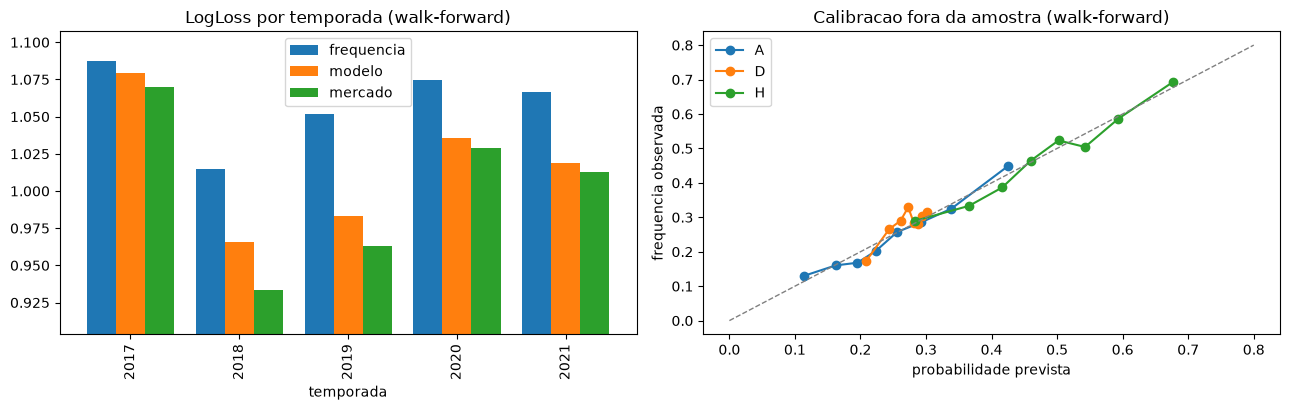

In [15]:
P_val = temper(P_ens["wf"], T_FINAL)
wf_seasons = seasons[-5:]
por_temporada = pd.DataFrame({
    "frequencia": [ll(P_freq_wf, (train.Season == s).to_numpy()) for s in wf_seasons],
    "modelo": [ll(P_val, (train.Season == s).to_numpy()) for s in wf_seasons],
    "mercado": [cross_entropy(Y_all, M_all, (train.Season == s).to_numpy()) for s in wf_seasons],
}, index=wf_seasons)
print(por_temporada.round(4))

wf_mask = ~np.isnan(P_val[:, 0])
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
por_temporada.plot(kind="bar", ax=axes[0], width=0.8)
axes[0].set_ylim(por_temporada.min().min() - 0.03, por_temporada.max().max() + 0.02)
axes[0].set_title("LogLoss por temporada (walk-forward)")
axes[0].set_xlabel("temporada")

# calibracao: probabilidade prevista x frequencia observada, por faixa
for j, c in enumerate(CLASSES):
    p, y = P_val[wf_mask, j], Y_all[wf_mask, j]
    gb = pd.DataFrame({"p": p, "y": y}).groupby(pd.qcut(p, 8, duplicates="drop"), observed=True).mean()
    axes[1].plot(gb.p, gb.y, marker="o", label=c)
axes[1].plot([0, 0.8], [0, 0.8], color="gray", linestyle="--", linewidth=1)
axes[1].set_title("Calibracao fora da amostra (walk-forward)")
axes[1].set_xlabel("probabilidade prevista")
axes[1].set_ylabel("frequencia observada")
axes[1].legend()
plt.tight_layout()
plt.show()

## 10. Treino final

Os genomas escolhidos são retreinados com todas as temporadas do treino. A função `predict` recebe um DataFrame de partidas e devolve as probabilidades, passando por `build_features`, pelos modelos do ensemble e pela temperatura.

O mesmo conjunto de genomas é treinado uma segunda vez sem a feature de regime, para gerar a submissão alternativa.

In [16]:
todas = np.ones(len(train), dtype=bool)
modelos = {
    "com_regime": [fit_genome(g, todas) for g in escolhidos],
    "sem_regime": [fit_genome(dict(g, regime=False), todas) for g in escolhidos],
}


def predict(df, variante="com_regime"):
    X = build_features(df)
    P = np.mean([m.predict_proba(X) for m in modelos[variante]], axis=0)
    return temper(P, T_FINAL)


for variante in modelos:
    P = predict(test, variante)
    print(variante, "| media prevista A, D, H:", P.mean(0).round(4))
print("frequencia no treino     A, D, H:", Y_all.mean(0).round(4))

com_regime | media prevista A, D, H: [0.2503 0.2696 0.4801]
sem_regime | media prevista A, D, H: [0.2652 0.2732 0.4616]
frequencia no treino     A, D, H: [0.2401 0.2682 0.4917]


## 11. Verificação da regra da linha própria

A célula abaixo testa a regra de forma direta. Ela prevê 300 partidas do teste uma de cada vez, em ordem embaralhada, e compara com a previsão feita em lote. Se qualquer etapa do pipeline dependesse de outras linhas do teste, os dois resultados seriam diferentes.

In [17]:
rng = np.random.default_rng(SEED)
amostra = rng.permutation(len(test))[:300]
for variante in modelos:
    P_lote = predict(test, variante)
    P_uma_a_uma = np.vstack([predict(test.iloc[[i]], variante) for i in amostra])
    assert np.allclose(P_uma_a_uma, P_lote[amostra], atol=1e-10), "a previsao depende de outras linhas do teste"
    print(variante, "| previsao linha a linha bate com a previsao em lote:", True)

com_regime | previsao linha a linha bate com a previsao em lote: True


sem_regime | previsao linha a linha bate com a previsao em lote: True


## 12. Arquivos de submissão

As colunas saem na ordem `Id, A, D, H`. As checagens abaixo cobrem os erros que dão score errado sem aviso: ordem de colunas, soma diferente de 1, valores ausentes e Ids fora do template.

O arquivo principal é o `submission.csv`, com a feature de regime. O `submission_sem_regime.csv` é a alternativa para a segunda vaga de submissão final.

In [18]:
def write_submission(P, caminho):
    sub = pd.DataFrame(P, columns=CLASSES)
    sub.insert(0, "Id", test.Id.to_numpy())
    sub = sub.set_index("Id").loc[sample.Id].reset_index()  # mesma ordem do template
    assert list(sub.columns) == ["Id", "A", "D", "H"]
    assert list(sub.columns) == list(sample.columns)
    assert len(sub) == len(test) == len(sample)
    assert sub[CLASSES].notna().all().all()
    assert np.allclose(sub[CLASSES].sum(axis=1), 1.0)
    assert (sub[CLASSES] > 0).all().all()
    sub.to_csv(caminho, index=False)
    return sub


sub = write_submission(predict(test, "com_regime"), "submission.csv")
sub_alt = write_submission(predict(test, "sem_regime"), "submission_sem_regime.csv")

print(sub.head())
print("\nmenor e maior probabilidade:", round(float(sub[CLASSES].min().min()), 4), round(float(sub[CLASSES].max().max()), 4))
print("diferenca media absoluta entre as duas submissoes:", round(float((sub[CLASSES] - sub_alt[CLASSES]).abs().mean().mean()), 4))

     Id         A         D         H
0  3419  0.217310  0.287771  0.494919
1  3420  0.398878  0.290151  0.310970
2  3421  0.171008  0.261062  0.567930
3  3422  0.236072  0.269161  0.494768
4  3423  0.131467  0.211886  0.656646

menor e maior probabilidade: 0.0431 0.8307
diferenca media absoluta entre as duas submissoes: 0.0127


## 13. Variantes por família

A busca prefere a família `ridge` pela nota `hard`, mas a nota `soft` das duas famílias lineares é praticamente igual. A célula abaixo mede a diferença entre os ensembles de `ridge` e de `logit` partida a partida, com o erro padrão de cada temporada, para separar o que é diferença real do que é sorte.

As duas variantes também viram arquivos de submissão na pasta `variantes/`, com a feature de regime ligada.

In [19]:
variantes = {
    "logit": fixar("logit", melhores(["logit"], TOP_K, TOP_K)),
    "ridge": fixar("ridge", melhores(["ridge"], TOP_K, TOP_K)),
}
Path("variantes").mkdir(exist_ok=True)
P_var = {}
for nome, gs in variantes.items():
    modelos[nome] = [fit_genome(g, todas) for g in gs]
    P_var[nome] = {k: np.mean([oof_predict(g, sp) for g in gs], axis=0) for k, sp in SPLITS.items()}
    write_submission(predict(test, nome), f"variantes/submission_{nome}.csv")
    print(nome, {k: round(v, 4) for k, v in score_predictions(P_var[nome]).items() if k in cols_nota})


def perda_por_partida(T, P):
    return -(T * np.log(np.clip(P, 1e-15, 1))).sum(axis=1)


Pr, Pl = P_var["ridge"]["long2"], P_var["logit"]["long2"]
ok = ~np.isnan(Pr[:, 0])
d_hard = perda_por_partida(Y_all, Pr) - perda_por_partida(Y_all, Pl)
d_soft = perda_por_partida(M_all, Pr) - perda_por_partida(M_all, Pl)
linhas = []
for s in sorted(train.Season[ok].unique()):
    m = ok & (train.Season == s).to_numpy()
    linhas.append(dict(temporada=int(s), hard=d_hard[m].mean(), erro_padrao=d_hard[m].std() / np.sqrt(m.sum()), soft=d_soft[m].mean()))
linhas.append(dict(temporada="todas", hard=d_hard[ok].mean(), erro_padrao=d_hard[ok].std() / np.sqrt(ok.sum()), soft=d_soft[ok].mean()))
print("\ndiferenca ridge menos logit no corte long2 (negativo favorece ridge):")
print(pd.DataFrame(linhas).round(4).to_string(index=False))

rng_b = np.random.default_rng(SEED)
idx = np.where(ok)[0]
sims = [d_hard[rng_b.choice(idx, 517, replace=False)].mean() for _ in range(2000)]
print("\ndesvio padrao da diferenca em amostras de 517 partidas (tamanho do placar publico):", round(float(np.std(sims)), 4))

logit: genomas gravados em artefatos/genomas_finais.json
ridge: genomas gravados em artefatos/genomas_finais.json


logit {'wf': 1.0172, 'long': 1.0065, 'long2': 1.0217, 'hard': 1.0151, 'soft': 1.0215, 'fitness': 1.0183, 'gap_meta': 0.0192}


ridge {'wf': 1.0166, 'long': 1.0052, 'long2': 1.0207, 'hard': 1.0141, 'soft': 1.0215, 'fitness': 1.0178, 'gap_meta': 0.0182}

diferenca ridge menos logit no corte long2 (negativo favorece ridge):
temporada    hard  erro_padrao    soft
     2017  0.0014       0.0017  0.0001
     2018 -0.0046       0.0014 -0.0007
     2019 -0.0020       0.0017 -0.0004
     2020  0.0008       0.0017  0.0002
     2021 -0.0007       0.0016 -0.0004
    todas -0.0010       0.0007 -0.0002

desvio padrao da diferenca em amostras de 517 partidas (tamanho do placar publico): 0.0012


A diferença entre as famílias muda de sinal de uma temporada para outra, e a vantagem do `ridge` na nota `hard` vem principalmente de 2018. Na nota `soft` a diferença fica perto de zero em todas as temporadas. As duas famílias são equivalentes dentro do ruído, e é por isso que o modelo final mistura as duas em vez de escolher uma.

O último número da célula dá a escala para ler o placar público. Duas submissões que diferem só na família podem ficar a 0.002 uma da outra no placar público por puro acaso.

## 14. Fechamento

O score esperado no placar privado é o da validação, com uma folga para cima, porque o teste cobre temporadas mais distantes do treino do que qualquer corte de validação e porque a seleção de configurações sempre carrega algum otimismo. O placar público usa só 30% do teste e tem ruído de cerca de 0.018, então ele não entra em nenhuma decisão deste notebook.

O limite do modelo está na informação disponível. As colunas descrevem força e momento dos times, mas não trazem escalação, lesões ou contexto de tabela, que são justamente o que o mercado sabe a mais. A busca evolutiva testou oito famílias de modelos e centenas de configurações, e todas as boas soluções pararam no mesmo platô. Por isso qualquer score muito próximo de 1.000 com essas colunas seria sinal de vazamento, não de modelo melhor.

A decisão que mais pode mexer no resultado é a do regime. Ela é uma aposta de que a vantagem do mandante em 2022 em diante se parece com a das partidas fora da janela de agosto de 2020 a setembro de 2021. A evidência do treino aponta nessa direção, mas não fecha a questão, e é por isso que existem dois arquivos de submissão.